# Instalar dependencias

In [3]:
import subprocess

subprocess.run(['pip', 'install', 'nibabel', 'scipy', 'scikit-image',
                'trimesh', 'numpy', 'pandas', 'matplotlib', 'tqdm', '-q'])
subprocess.run(['pip', 'install', 'pyvista', 'vtk', '-q'])
print('✓ Dependencias instaladas')

✓ Dependencias instaladas


# Imports

In [4]:
import numpy as np
import nibabel as nib
import trimesh
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pyvista as pv
import random
from pathlib import Path
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from skimage.measure import marching_cubes
from skimage.transform import resize
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Activar display virtual (Colab no tiene pantalla física)
import subprocess
subprocess.Popen(['Xvfb', ':99', '-screen', '0', '1024x768x24'])
import os
os.environ['DISPLAY'] = ':99'

# Configurar PyVista para modo offscreen
pv.global_theme.multi_rendering_splitting_position = None
pv.global_theme.trame.jupyter_extension_enabled = False

print('✓ Imports OK')

✓ Imports OK


# Rutas

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/VerSe_2020_Dataset'

PRED_DIRS = {
    'nnUNet':    f'{DRIVE_BASE}/results/nnunet/inference_3d_lowres_postprocessed',
    'MedNeXt':   f'{DRIVE_BASE}/results/mednext/inference_3d_lowres_postprocessed',
    'SwinUNETR': f'{DRIVE_BASE}/results/swinunetr/inference_3d_lowres_postprocessed',
}

GT_DIR     = f'{DRIVE_BASE}/preprocessed_verse_for_training/nnUNet_raw/Dataset507_VerSe2020/labelsTs'
OUTPUT_DIR = Path(f'{DRIVE_BASE}/mesh_output')
STL_DIR    = OUTPUT_DIR / 'stl'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STL_DIR.mkdir(exist_ok=True)

print('✓ Rutas configuradas')
for name, path in PRED_DIRS.items():
    exists = Path(path).exists()
    n = len(list(Path(path).glob('*.nii.gz'))) if exists else 0
    print(f'  {name}: {"✓" if exists else "✗"} — {n} casos')
gt_n = len(list(Path(GT_DIR).glob('*.nii.gz')))
print(f'  GT:      ✓ — {gt_n} casos')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Rutas configuradas
  nnUNet: ✓ — 113 casos
  MedNeXt: ✓ — 113 casos
  SwinUNETR: ✓ — 113 casos
  GT:      ✓ — 113 casos


# Seleccionar 10 casos al azar

In [6]:
random.seed(42)  # semilla fija — siempre los mismos 10 casos

# Casos disponibles en GT
all_cases = sorted([f.name for f in Path(GT_DIR).glob('*.nii.gz')])

# Filtrar solo los que existen en todos los modelos
valid_cases = [
    case for case in all_cases
    if all((Path(pred_dir) / case).exists() for pred_dir in PRED_DIRS.values())
]

# Seleccionar 10 al azar
selected_cases = sorted(random.sample(valid_cases, min(10, len(valid_cases))))

print(f'✓ {len(selected_cases)} casos seleccionados:\n')
for i, case in enumerate(selected_cases, 1):
    print(f'  {i:2d}. {case}')

✓ 10 casos seleccionados:

   1. VerSe_test_0004.nii.gz
   2. VerSe_test_0014.nii.gz
   3. VerSe_test_0015.nii.gz
   4. VerSe_test_0018.nii.gz
   5. VerSe_test_0029.nii.gz
   6. VerSe_test_0032.nii.gz
   7. VerSe_test_0036.nii.gz
   8. VerSe_test_0082.nii.gz
   9. VerSe_test_0087.nii.gz
  10. VerSe_test_0095.nii.gz


# Pipeline de reconstrucción 3D

In [7]:
def resample_to_isotropic(mask_nib, target_spacing=1.0):
    """Resample máscara a espaciado isótropo 1mm."""
    data      = mask_nib.get_fdata().astype(np.float32)
    zooms     = mask_nib.header.get_zooms()[:3]
    new_shape = tuple(
        int(round(s * z / target_spacing))
        for s, z in zip(data.shape, zooms)
    )
    resampled = resize(
        data, new_shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(np.uint8)
    return resampled

def mask_to_stl(mask_path, stl_path, sigma=1.0, target_spacing=1.0):
    """
    Pipeline 3 pasos:
    1. Resample a 1mm isótropo
    2. Gaussian filter
    3. Marching Cubes → STL
    """
    mask_nib  = nib.load(str(mask_path))
    resampled = resample_to_isotropic(mask_nib, target_spacing)
    binary    = (resampled > 0).astype(np.float32)

    if binary.sum() == 0:
        print(f'  ⚠ Máscara vacía: {Path(mask_path).name}')
        return None

    smoothed = gaussian_filter(binary, sigma=sigma)

    verts, faces, normals, _ = marching_cubes(
        smoothed,
        level=0.5,
        spacing=(target_spacing, target_spacing, target_spacing)
    )

    mesh = trimesh.Trimesh(vertices=verts, faces=faces, vertex_normals=normals)
    mesh.export(str(stl_path))
    return mesh

def sample_surface_points(mesh, n_points=10000):
    points, _ = trimesh.sample.sample_surface(mesh, n_points)
    return points

def compute_geometric_metrics(mesh_pred, mesh_gt, n_points=10000):
    pts_pred = sample_surface_points(mesh_pred, n_points)
    pts_gt   = sample_surface_points(mesh_gt,   n_points)

    tree_gt   = cKDTree(pts_gt)
    tree_pred = cKDTree(pts_pred)

    dist_pred_to_gt, _ = tree_gt.query(pts_pred)
    dist_gt_to_pred, _ = tree_pred.query(pts_gt)

    bidir_mean  = (dist_pred_to_gt.mean() + dist_gt_to_pred.mean()) / 2
    vertex_mean = dist_pred_to_gt.mean()
    p95         = np.percentile(dist_pred_to_gt, 95)
    hausdorff   = max(dist_pred_to_gt.max(), dist_gt_to_pred.max())

    return {
        'vertices':           len(mesh_pred.vertices),
        'faces':              len(mesh_pred.faces),
        'surface_area_mm2':   round(mesh_pred.area, 2),
        'volume_mm3':         round(abs(mesh_pred.volume), 2),
        'bidir_mean_dev_mm':  round(bidir_mean, 4),
        'vertex_mean_err_mm': round(vertex_mean, 4),
        'p95_err_mm':         round(p95, 4),
        'max_hausdorff_mm':   round(hausdorff, 4),
    }

print('✓ Funciones definidas')

✓ Funciones definidas


# Métricas geométricas

In [8]:
def sample_surface_points(mesh, n_points=10000):
    points, _ = trimesh.sample.sample_surface(mesh, n_points)
    return points

def compute_geometric_metrics(mesh_pred, mesh_gt, n_points=10000):
    pts_pred = sample_surface_points(mesh_pred, n_points)
    pts_gt   = sample_surface_points(mesh_gt,   n_points)

    tree_gt   = cKDTree(pts_gt)
    tree_pred = cKDTree(pts_pred)

    dist_pred_to_gt, _ = tree_gt.query(pts_pred)
    dist_gt_to_pred, _ = tree_pred.query(pts_gt)

    # ASSD — bidireccional promedio
    assd = (dist_pred_to_gt.mean() + dist_gt_to_pred.mean()) / 2

    # Chamfer — promedio pred→GT (distancia media de vértices)
    chamfer = dist_pred_to_gt.mean()

    # HD95 — percentil 95 BIDIRECCIONAL (estándar MICCAI)
    all_distances = np.concatenate([dist_pred_to_gt, dist_gt_to_pred])
    hd95 = np.percentile(all_distances, 95)

    # Hausdorff máximo
    hausdorff = max(dist_pred_to_gt.max(), dist_gt_to_pred.max())

    # Volúmenes
    vol_pred = abs(mesh_pred.volume)
    vol_gt   = abs(mesh_gt.volume)
    vol_err  = abs(vol_pred - vol_gt) / (vol_gt + 1e-8) * 100

    return {
        'vertices':       len(mesh_pred.vertices),
        'faces':          len(mesh_pred.faces),
        'surface_area_mm2': round(mesh_pred.area, 2),
        'volume_mm3':     round(vol_pred, 2),
        'ASSD_mm':        round(assd, 4),
        'Chamfer_mm':     round(chamfer, 4),
        'HD95_mm':        round(hd95, 4),
        'Hausdorff_mm':   round(hausdorff, 4),
        'vol_error_pct':  round(vol_err, 4),
    }

print('✓ compute_geometric_metrics actualizada')

✓ compute_geometric_metrics actualizada


# Generar STLs para el caso de prueba

In [9]:
meshes      = {}   # {case: {model: mesh}}
results_all = []   # métricas de todos los casos

for case in tqdm(selected_cases, desc='Procesando casos'):
    meshes[case] = {}
    case_id = case.replace('.nii.gz', '')

    # Ground Truth
    gt_path = Path(GT_DIR) / case
    gt_stl  = STL_DIR / f'gt_{case_id}.stl'
    meshes[case]['GT'] = mask_to_stl(gt_path, gt_stl)

    if meshes[case]['GT'] is None:
        print(f'  ✗ {case}: GT vacío — saltando')
        continue

    # Modelos
    for model_name, pred_dir in PRED_DIRS.items():
        pred_path = Path(pred_dir) / case
        stl_path  = STL_DIR / f'{model_name}_{case_id}.stl'

        if not pred_path.exists():
            print(f'  ✗ {model_name}/{case}: no encontrado')
            meshes[case][model_name] = None
            continue

        meshes[case][model_name] = mask_to_stl(pred_path, stl_path)

        if meshes[case][model_name] is not None:
            metrics = compute_geometric_metrics(
                meshes[case][model_name], meshes[case]['GT']
            )
            metrics['case']  = case
            metrics['model'] = model_name
            results_all.append(metrics)

print(f'\n✓ {len(results_all)} métricas calculadas')
print(f'✓ STLs guardados en {STL_DIR}')

Procesando casos:   0%|          | 0/10 [00:00<?, ?it/s]


✓ 30 métricas calculadas
✓ STLs guardados en /content/drive/MyDrive/VerSe_2020_Dataset/mesh_output/stl


# Calcular métricas geométricas

In [10]:
df_all = pd.DataFrame(results_all)

# Promedio por modelo
df_mean = df_all.groupby('model').agg({
    'vertices':         'mean',
    'faces':            'mean',
    'surface_area_mm2': 'mean',
    'volume_mm3':       'mean',
    'ASSD_mm':          'mean',
    'Chamfer_mm':       'mean',
    'HD95_mm':          'mean',
    'Hausdorff_mm':     'mean',
    'vol_error_pct':    'mean',
}).round(4)

# Reordenar filas
df_mean = df_mean.reindex(['nnUNet', 'MedNeXt', 'SwinUNETR'])

print('\n── Métricas geométricas promedio (10 casos) ──────────────')
print(df_mean[['ASSD_mm', 'Chamfer_mm', 'HD95_mm',
               'Hausdorff_mm', 'vol_error_pct']].to_string())

# Guardar
df_all.to_csv(str(OUTPUT_DIR  / 'geometric_metrics_all_cases.csv'), index=False)
df_mean.to_csv(str(OUTPUT_DIR / 'geometric_metrics_mean.csv'))
print(f'\n✓ CSVs guardados en Drive')

# Mejor modelo por métrica
print(f'\n  Mejor ASSD:          {df_mean["ASSD_mm"].idxmin()}')
print(f'  Mejor Chamfer:       {df_mean["Chamfer_mm"].idxmin()}')
print(f'  Mejor HD95:          {df_mean["HD95_mm"].idxmin()}')
print(f'  Mejor Hausdorff:     {df_mean["Hausdorff_mm"].idxmin()}')
print(f'  Menor error volumen: {df_mean["vol_error_pct"].idxmin()}')


── Métricas geométricas promedio (10 casos) ──────────────
           ASSD_mm  Chamfer_mm  HD95_mm  Hausdorff_mm  vol_error_pct
model                                                               
nnUNet      2.1726      2.4678   5.1571       27.5803         3.9394
MedNeXt     2.2003      2.3683   5.4631       24.9964         3.6610
SwinUNETR   2.3074      2.6164   5.7679       50.6482         6.4074

✓ CSVs guardados en Drive

  Mejor ASSD:          nnUNet
  Mejor Chamfer:       MedNeXt
  Mejor HD95:          nnUNet
  Mejor Hausdorff:     MedNeXt
  Menor error volumen: MedNeXt


# Paleta de colores y funciones de visualización

In [11]:
# ── Paleta de colores por vértebra (VerSe label map) ──────────────────────
VERT_LABELS = {
    1:'C1',  2:'C2',  3:'C3',  4:'C4',  5:'C5',  6:'C6',  7:'C7',
    8:'T1',  9:'T2', 10:'T3', 11:'T4', 12:'T5', 13:'T6', 14:'T7',
   15:'T8', 16:'T9',17:'T10',18:'T11',19:'T12',
   20:'L1', 21:'L2', 22:'L3', 23:'L4', 24:'L5',
   25:'S1',
}

VERT_COLORS_HEX = {
     1:'#e6194b',  2:'#f58231',  3:'#ffe119',  4:'#3cb44b',  5:'#42d4f4',
     6:'#4363d8',  7:'#911eb4',  8:'#f032e6',  9:'#bfef45', 10:'#fabebe',
    11:'#469990', 12:'#e6beff', 13:'#9A6324', 14:'#800000', 15:'#aaffc3',
    16:'#808000', 17:'#ffd8b1', 18:'#000075', 19:'#808080', 20:'#e6194b',
    21:'#f58231', 22:'#ffe119', 23:'#3cb44b', 24:'#42d4f4', 25:'#ff4444',
}

def hex_to_rgb01(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))

print('✓ Paleta definida')


✓ Paleta definida


In [30]:
def get_mesh_bounds(mesh_trimesh):
    v = mesh_trimesh.vertices
    return [v[:,0].min(), v[:,0].max(),
            v[:,1].min(), v[:,1].max(),
            v[:,2].min(), v[:,2].max()]


def render_mesh_3d_pyvista(mesh_trimesh, elev=10, azim=180, zoom=1,
                            camera_bounds=None):
    faces_pv = np.hstack([
        np.full((len(mesh_trimesh.faces), 1), 3),
        mesh_trimesh.faces
    ])
    cloud = pv.PolyData(mesh_trimesh.vertices.astype(float), faces_pv)
    cloud = cloud.clean()

    pl = pv.Plotter(off_screen=True, window_size=[1200, 900])
    pl.set_background('white')

    pl.add_mesh(
        cloud,
        color='#b0b0b0',
        smooth_shading=True,
        specular=0.4,
        specular_power=20,
        diffuse=0.8,
        ambient=0.25,
        show_edges=False,
    )

    if camera_bounds is not None:
        pl.reset_camera(bounds=camera_bounds)
    else:
        pl.reset_camera()

    pl.camera.elevation = elev
    pl.camera.azimuth   = azim
    pl.camera.zoom(zoom)

    img = pl.screenshot(return_img=True)
    pl.close()
    return img


def render_comparison_3d(meshes_dict, viz_case, subtitles=None, output_path=None):
    """
    Figura comparativa 2x2 con escala fija basada en el GT.
    """
    model_names = ['GT', 'nnUNet', 'MedNeXt', 'SwinUNETR']
    if subtitles is None:
        subtitles = ['a) GT', 'b) nnUNet', 'c) MedNeXt', 'd) SwinUNETR']

    # Obtener bounds del GT para fijar escala igual en todos
    gt_mesh   = meshes_dict.get(viz_case, {}).get('GT')
    gt_bounds = get_mesh_bounds(gt_mesh) if gt_mesh is not None else None

    renders = []
    for name in model_names:
        mesh = meshes_dict.get(viz_case, {}).get(name)
        if mesh is not None:
            renders.append(render_mesh_3d_pyvista(mesh, camera_bounds=gt_bounds))
        else:
            renders.append(None)

    # Figura 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='white')
    case_label = viz_case.replace('.nii.gz', '')
    fig.suptitle(case_label, fontsize=36, y=1.01, color='#333333')

    for ax, img, label in zip(axes.flatten(), renders, subtitles):
        ax.set_facecolor('white')
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'No disponible', ha='center', va='center',
                    transform=ax.transAxes, color='red', fontsize=12)
        ax.axis('off')
        ax.text(0.5, -0.02, label, transform=ax.transAxes,
                ha='center', va='top', fontsize=28, color='black')

    plt.tight_layout(pad=2.0)
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'✓ Guardado -> {output_path}')
    plt.show()
    return fig

print('✓ Funciones PyVista definidas')

✓ Funciones PyVista definidas


In [39]:
def plot_sagittal_slice(ct_data, mask_data, ax, offset=0,
                        window_center=400, window_width=1800,
                        title='', title_fontsize=28):
    mid = int(ct_data.shape[0] // 2) + offset
    mid = int(np.clip(mid, 0, ct_data.shape[0] - 1))

    ct_sl   = ct_data[mid, :, :]
    mask_sl = mask_data[mid, :, :].astype(int)

    lo = window_center - window_width / 2
    hi = window_center + window_width / 2
    ct_norm = (np.clip(ct_sl, lo, hi) - lo) / (hi - lo)

    ax.imshow(ct_norm.T, cmap='gray', origin='lower', aspect='auto')

    overlay = np.zeros((*ct_norm.T.shape, 4))
    for label, hex_c in VERT_COLORS_HEX.items():
        region = (mask_sl == label).T
        if region.any():
            r, g, b = hex_to_rgb01(hex_c)
            overlay[region] = [r, g, b, 0.55]
    ax.imshow(overlay, origin='lower', aspect='auto')

    for label, name in VERT_LABELS.items():
        region = (mask_sl == label).T
        if region.any():
            ys, xs = np.where(region)
            ax.text(xs.mean(), ys.mean(), name,
                    color='white', fontsize=11, fontweight='bold',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='black',
                              alpha=0.35, edgecolor='none'))

    if title:
        ax.set_title(title,
                     fontsize=title_fontsize,
                     fontweight='bold',
                     color='black', pad=6)
    ax.set_facecolor('white')
    ax.axis('off')

print('✓ plot_sagittal_slice actualizada')

✓ plot_sagittal_slice actualizada


# Visualización 3D — comparación de modelos

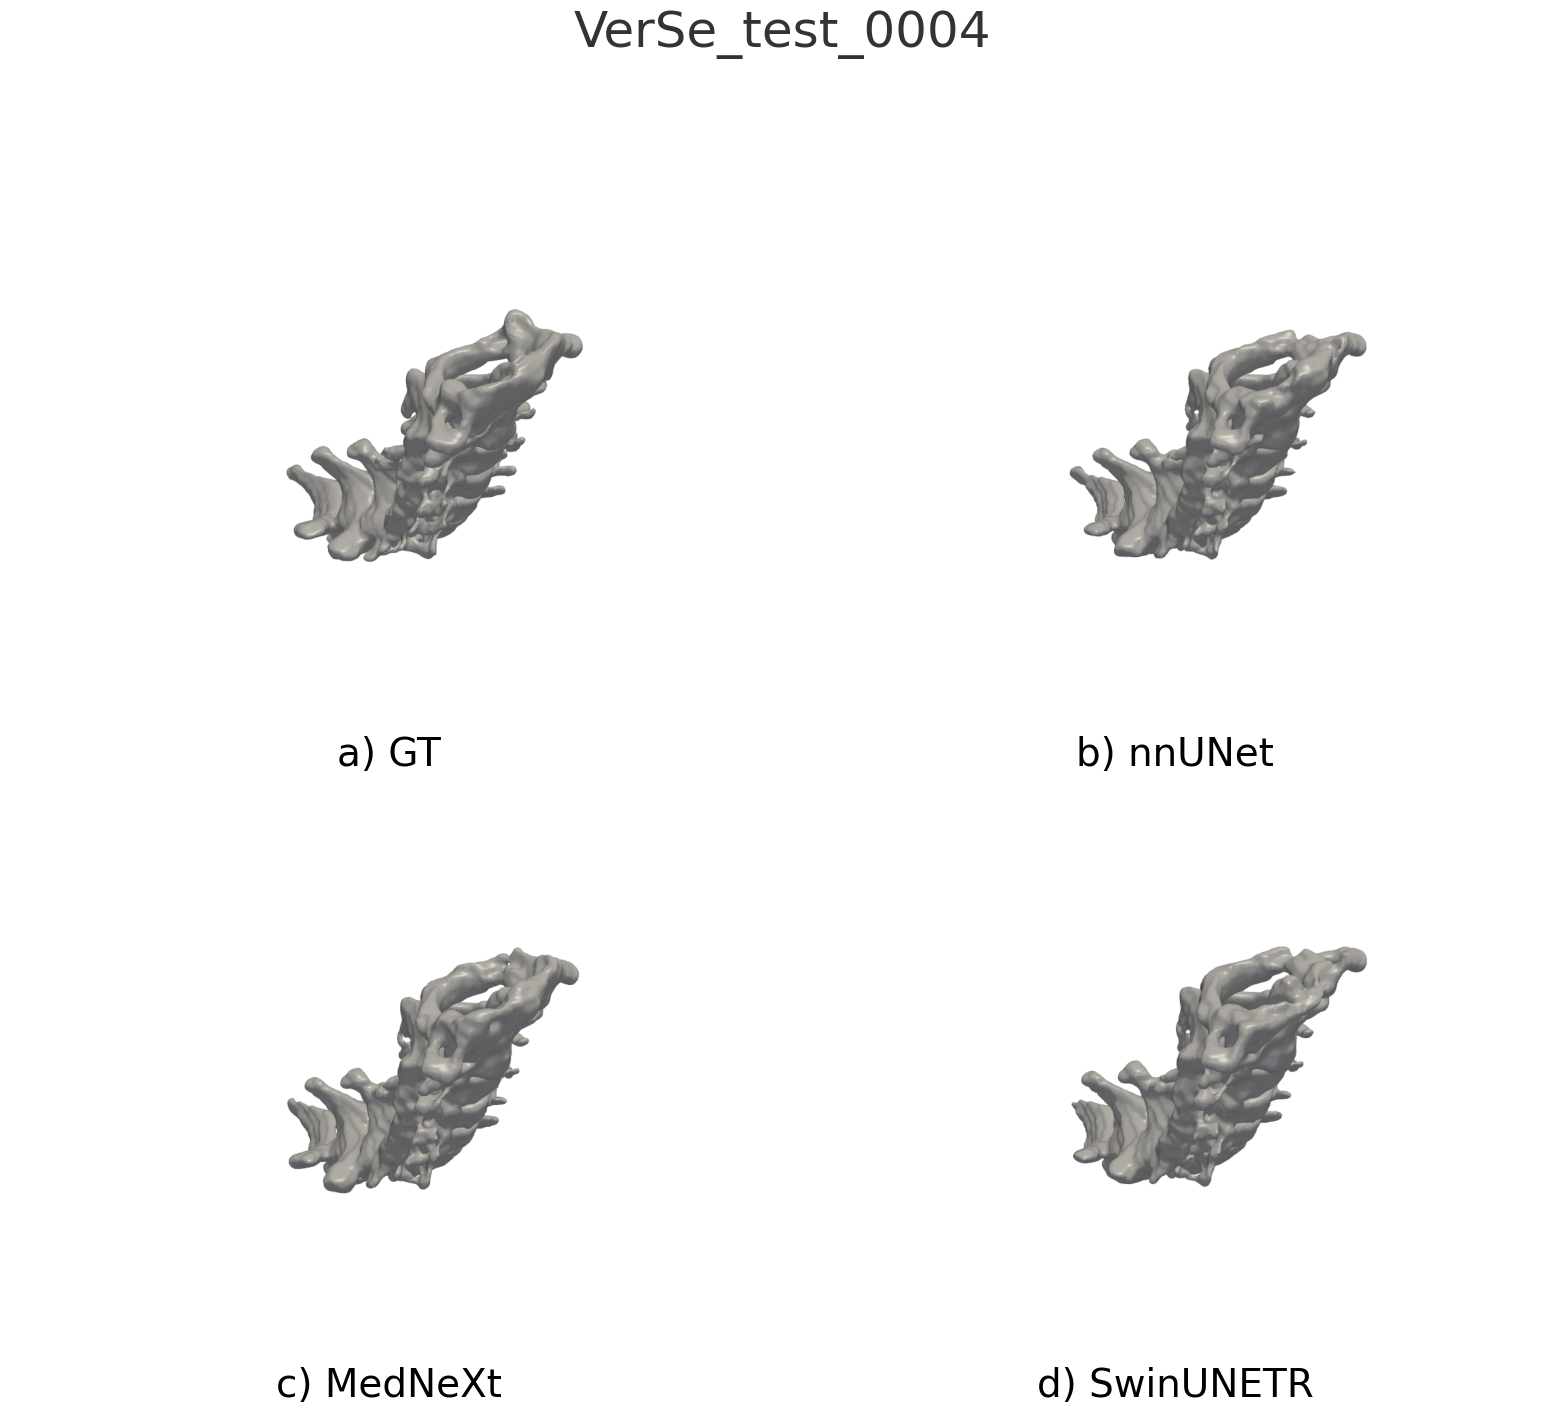

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/mesh_output/fig_3d_comparison.png


In [32]:
# ── Figura 3D 2x2: GT vs nnUNet vs MedNeXt vs SwinUNETR ──────────────────
viz_case    = selected_cases[0]
model_names = ['GT', 'nnUNet', 'MedNeXt', 'SwinUNETR']
subtitles   = ['a) GT', 'b) nnUNet', 'c) MedNeXt', 'd) SwinUNETR']

# Renderizar
renders = []
for name in model_names:
    mesh = meshes.get(viz_case, {}).get(name)
    renders.append(render_mesh_3d_pyvista(mesh) if mesh is not None else None)

# Figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='white')
fig.suptitle(viz_case.replace('.nii.gz', ''), fontsize=36,
             color='#333333', y=1.01)

for ax, img, subtitle in zip(axes.flatten(), renders, subtitles):
    ax.set_facecolor('white')
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'No disponible', ha='center', va='center',
                transform=ax.transAxes, color='red', fontsize=12)
    ax.axis('off')
    ax.text(0.5, -0.02, subtitle, transform=ax.transAxes,
            ha='center', va='top', fontsize=28, color='black')

plt.tight_layout(pad=2.0)
out_path = str(OUTPUT_DIR / 'fig_3d_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Guardado → {out_path}')

In [36]:
# ── 2x2 para TODOS los casos ──────────────────────────────────────────────
for viz_case in tqdm(selected_cases, desc='Renderizando 3D 2x2'):
    case_id   = viz_case.replace('.nii.gz', '')
    out_path  = str(OUTPUT_DIR / f'fig_3d_{case_id}.png')

    render_comparison_3d(
        meshes_dict = meshes,
        viz_case    = viz_case,
        subtitles   = ['a) GT', 'b) nnUNet', 'c) MedNeXt', 'd) SwinUNETR'],
        output_path = out_path
    )

    plt.close('all')

print(f'✓ {len(selected_cases)} figuras 3D guardadas en {OUTPUT_DIR}')

Output hidden; open in https://colab.research.google.com to view.

# Visualización CT + segmentación por vértebra

> **Nota:** Requiere los volúmenes CT originales (imágenes, no solo máscaras).
> Ajusta `CT_DIR` si tus CTs están en otra ruta dentro de Drive.


In [16]:
# ── Ruta a los CTs — AJUSTA SI ES NECESARIO ──────────────────────────────
CT_DIR = f'{DRIVE_BASE}/preprocessed_verse_for_training/nnUNet_raw/Dataset507_VerSe2020/imagesTs'

ct_files = list(Path(CT_DIR).glob('*.nii.gz')) if Path(CT_DIR).exists() else []
print(f'CT_DIR : {CT_DIR}')
print(f'CTs encontrados: {len(ct_files)}')

if not ct_files:
    print('⚠ No se encontraron CTs. Ajusta CT_DIR antes de continuar.')
else:
    print('✓ CTs disponibles')


CT_DIR : /content/drive/MyDrive/VerSe_2020_Dataset/preprocessed_verse_for_training/nnUNet_raw/Dataset507_VerSe2020/imagesTs
CTs encontrados: 113
✓ CTs disponibles


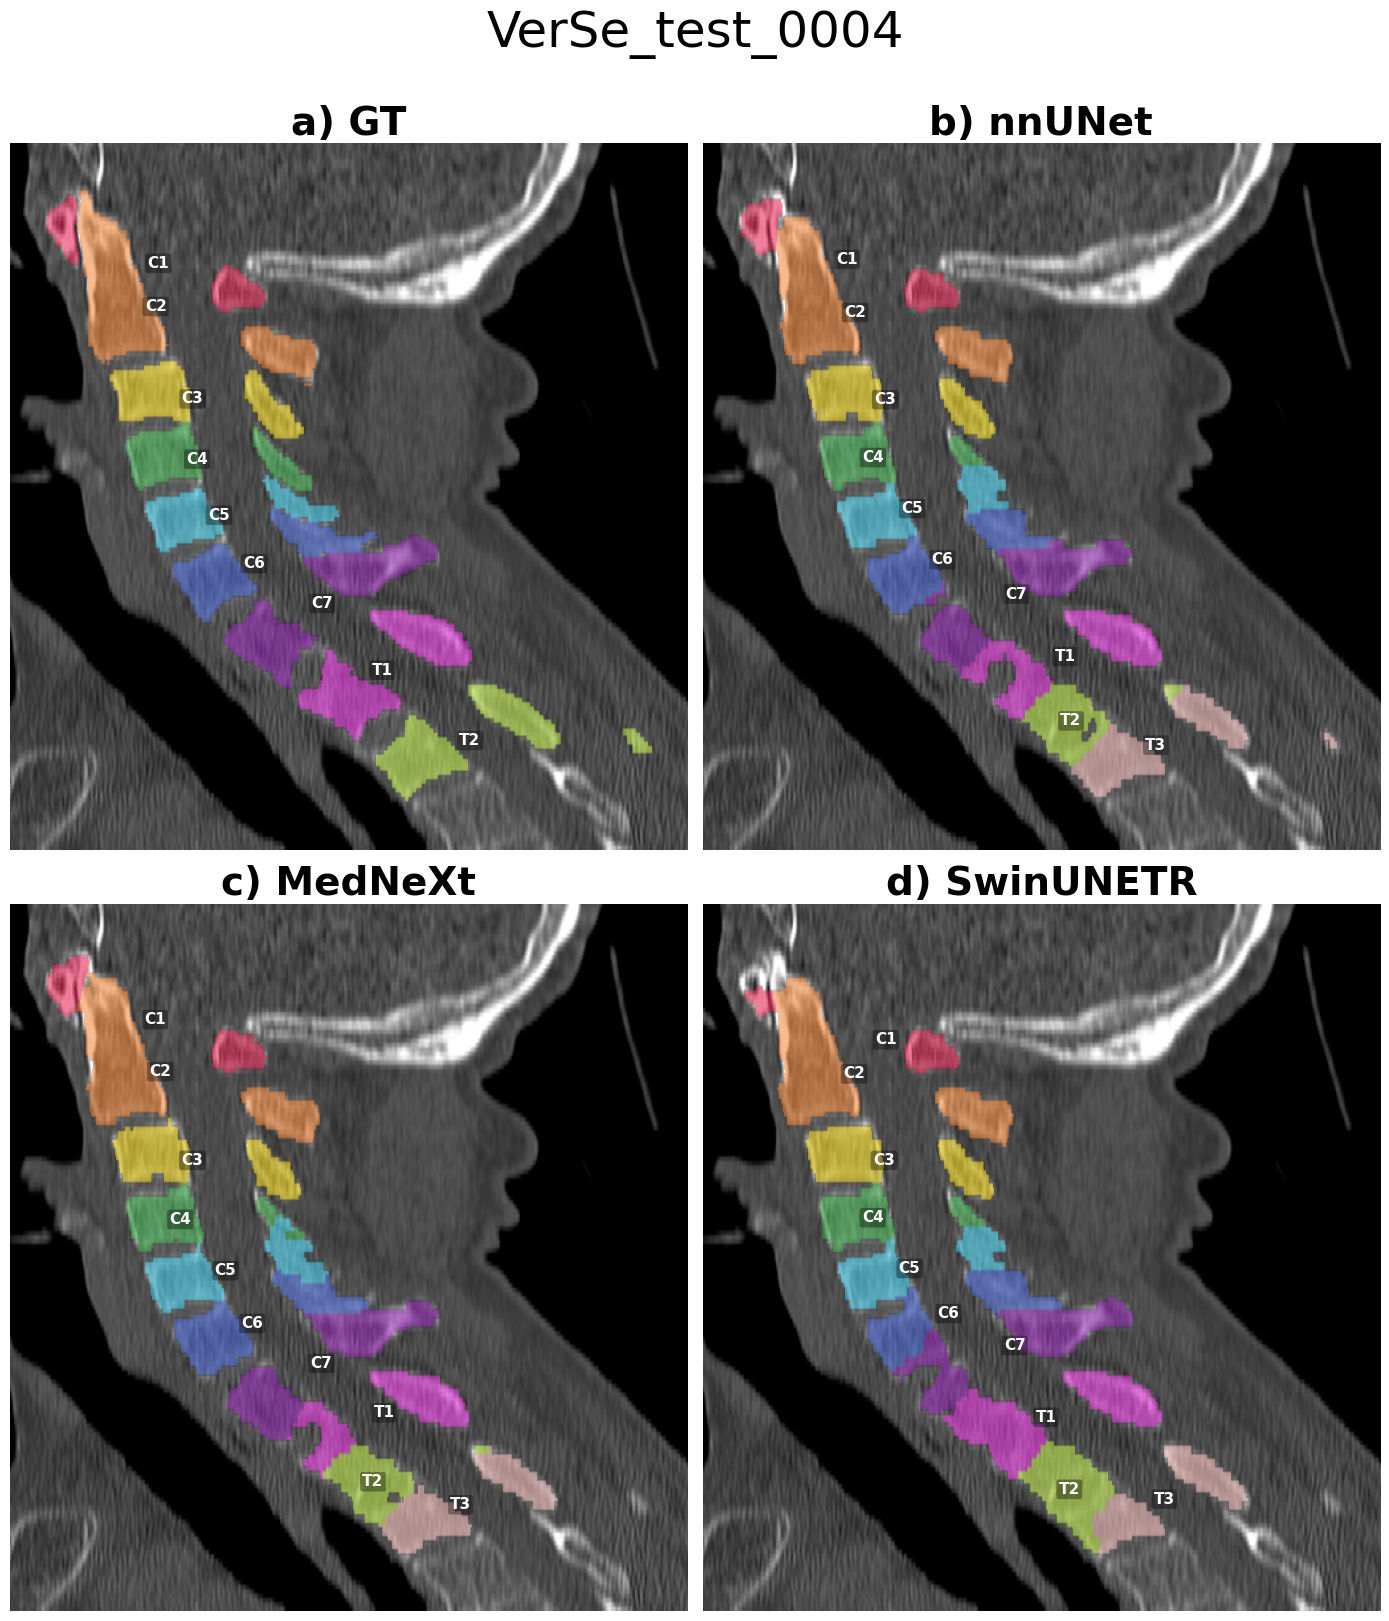

✓ Guardado -> /content/drive/MyDrive/VerSe_2020_Dataset/mesh_output/fig_ct_segmentation.png


In [43]:
# ── Figura CT + segmentacion: cuadricula 2x2, 1 slice por panel ──────────
viz_case = selected_cases[0]

layout = [
    ('GT',         Path(GT_DIR)                / viz_case,  'a) GT'),
    ('nnUNet',     Path(PRED_DIRS['nnUNet'])    / viz_case,  'b) nnUNet'),
    ('MedNeXt',    Path(PRED_DIRS['MedNeXt'])   / viz_case,  'c) MedNeXt'),
    ('SwinUNETR',  Path(PRED_DIRS['SwinUNETR']) / viz_case,  'd) SwinUNETR'),
]

ct_path = Path(CT_DIR) / viz_case
if not ct_path.exists():
    ct_path = Path(CT_DIR) / viz_case.replace('.nii.gz', '_0000.nii.gz')

if not ct_path.exists():
    print(f'⚠ CT no encontrado: {ct_path}')
else:
    ct_data = nib.load(str(ct_path)).get_fdata()

    fig, axes = plt.subplots(2, 2, figsize=(14, 16), facecolor='white')  # ← white
    fig.suptitle(f'{viz_case.replace(".nii.gz", "")}',
                 fontsize=36, color='black', y=1.01)                     # ← black

    for ax, (model, mask_path, subtitle) in zip(axes.flatten(), layout):
        ax.set_facecolor('white')                                        # ← white
        if not mask_path.exists():
            ax.text(0.5, 0.5, f'{subtitle}\nNo encontrado',
                    transform=ax.transAxes, ha='center', va='center',
                    color='black', fontsize=10)                          # ← black
            ax.axis('off')
            continue
        mask_data = nib.load(str(mask_path)).get_fdata().astype(int)
        plot_sagittal_slice(ct_data, mask_data, ax, offset=0, title=subtitle)

    plt.tight_layout()
    out_path = str(OUTPUT_DIR / 'fig_ct_segmentation.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')  # ← white
    plt.show()
    print(f'✓ Guardado -> {out_path}')

In [42]:
# ── CT + segmentacion 2x2 para todos los casos ────────────────────────────
ct_ok = Path(CT_DIR).exists() and len(list(Path(CT_DIR).glob('*.nii.gz'))) > 0

if not ct_ok:
    print('⚠ CT_DIR sin archivos. Ajusta CT_DIR arriba.')
else:
    for viz_case in tqdm(selected_cases, desc='CT + segmentacion'):
        case_id = viz_case.replace('.nii.gz', '')

        ct_path = Path(CT_DIR) / viz_case
        if not ct_path.exists():
            ct_path = Path(CT_DIR) / viz_case.replace('.nii.gz', '_0000.nii.gz')
        if not ct_path.exists():
            print(f'  ⚠ CT no encontrado: {viz_case}')
            continue

        ct_data = nib.load(str(ct_path)).get_fdata()

        layout = [
            ('GT',        Path(GT_DIR)                 / viz_case, 'a) GT'),
            ('nnUNet',    Path(PRED_DIRS['nnUNet'])     / viz_case, 'b) nnUNet'),
            ('MedNeXt',   Path(PRED_DIRS['MedNeXt'])    / viz_case, 'c) MedNeXt'),
            ('SwinUNETR', Path(PRED_DIRS['SwinUNETR'])  / viz_case, 'd) SwinUNETR'),
        ]

        fig, axes = plt.subplots(2, 2, figsize=(14, 16), facecolor='white')
        fig.suptitle(case_id,
                     fontsize=36,           # ← grande
                     color='black',
                     y=1.02)

        for ax, (model, mask_path, subtitle) in zip(axes.flatten(), layout):
            ax.set_facecolor('white')
            if not mask_path.exists():
                ax.text(0.5, 0.5, 'No encontrado',
                        transform=ax.transAxes, ha='center',
                        va='center', color='black', fontsize=10)
                ax.axis('off')
                continue
            mask_data = nib.load(str(mask_path)).get_fdata().astype(int)
            plot_sagittal_slice(ct_data, mask_data, ax, offset=0,
                                title=subtitle,
                                title_fontsize=28)   # ← pasar fontsize del subtítulo

        plt.tight_layout()
        out_path = str(OUTPUT_DIR / f'fig_ct_{case_id}.png')
        plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='white')
        plt.close()

    print(f'✓ Figuras CT guardadas en {OUTPUT_DIR}')

CT + segmentacion:   0%|          | 0/10 [00:00<?, ?it/s]

✓ Figuras CT guardadas en /content/drive/MyDrive/VerSe_2020_Dataset/mesh_output


In [25]:
from pathlib import Path

DRIVE_BASE = '/content/drive/MyDrive/VerSe_2020_Dataset'

print('── Notebooks encontrados ─────────────────────────────')
for nb in sorted(Path(DRIVE_BASE).rglob('*.ipynb')):
    size_mb = nb.stat().st_size / 1e6
    print(f'  {nb.relative_to(DRIVE_BASE)} ({size_mb:.1f} MB)')

print('\n── Scripts .py encontrados ───────────────────────────')
for py in sorted(Path(DRIVE_BASE).rglob('*.py')):
    print(f'  {py.relative_to(DRIVE_BASE)}')

print('\n── Estructura general ────────────────────────────────')
for item in sorted(Path(DRIVE_BASE).iterdir()):
    if item.is_dir():
        n_files = len(list(item.rglob('*')))
        size_gb = sum(f.stat().st_size for f in item.rglob('*') if f.is_file()) / 1e9
        print(f'  {item.name}/ ({n_files} archivos, {size_gb:.2f} GB)')
    else:
        print(f'  {item.name}')

── Notebooks encontrados ─────────────────────────────
  3D_MeshReconstruction.ipynb (1.2 MB)
  3D_MeshReconstruction_v2.ipynb (0.3 MB)
  3D_MeshReconstruction_v3.ipynb (1.6 MB)
  Inference_SwinUNETR.ipynb (0.1 MB)
  Inference_nnUNet.ipynb (0.1 MB)
  MedneXt_training.ipynb (0.7 MB)
  VerSe_Preproccessing.ipynb (0.3 MB)
  VerSe_Train_MedNeXt.ipynb (0.0 MB)
  VerSe_Train_SwinUNETR.ipynb (0.0 MB)
  VerSe_Training_nnUNet.ipynb (0.1 MB)
  Verse_Benchmark.ipynb (0.1 MB)
  computational_cost.ipynb (0.0 MB)
  nnUNet_results/3D_MeshReconstruction_v2.ipynb (0.1 MB)
  nnUNet_training.ipynb (0.0 MB)
  reconstruction/mesh_reconstruction.ipynb (0.0 MB)

── Scripts .py encontrados ───────────────────────────

── Estructura general ────────────────────────────────
  01_training.zip
  02_validation.zip
  03_test.zip
  3D_MeshReconstruction.ipynb
  3D_MeshReconstruction_v2.ipynb
  3D_MeshReconstruction_v3.ipynb
  3Dlowres_benchmark_results_MedNeXt/ (2 archivos, 0.00 GB)
  3Dlowres_benchmark_results_nnUN

# Barplot de métricas

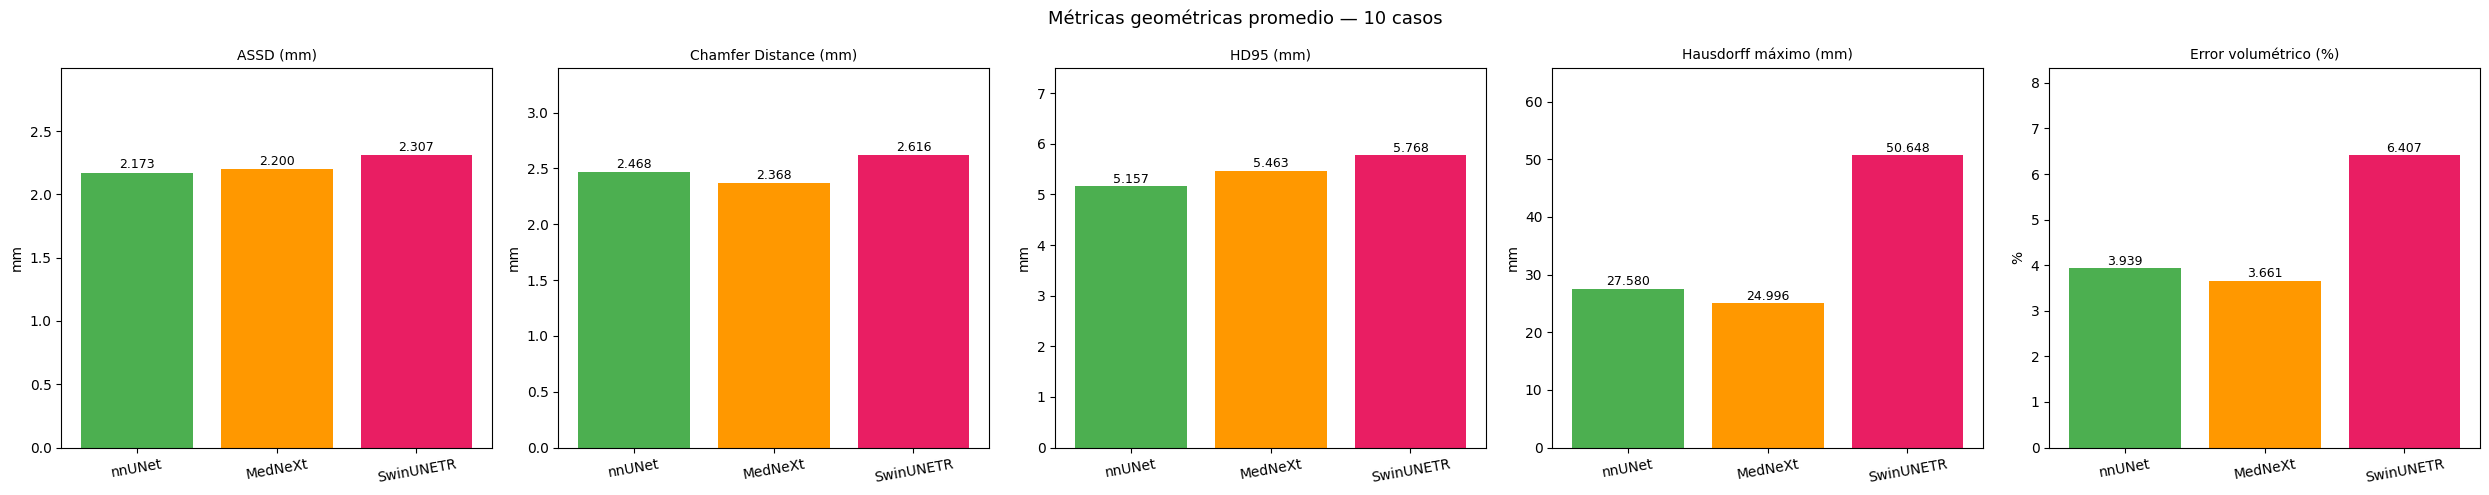

✓ Barplot guardado en Drive


In [19]:
metrics_to_plot = [
    ('ASSD_mm',       'ASSD (mm)'),
    ('Chamfer_mm',    'Chamfer Distance (mm)'),
    ('HD95_mm',       'HD95 (mm)'),
    ('Hausdorff_mm',  'Hausdorff máximo (mm)'),
    ('vol_error_pct', 'Error volumétrico (%)'),
]

fig, axes = plt.subplots(1, len(metrics_to_plot),
                         figsize=(5 * len(metrics_to_plot), 5))
colors = ['#4CAF50', '#FF9800', '#E91E63']

for ax, (col, title) in zip(axes, metrics_to_plot):
    vals = df_mean[col]
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('mm' if 'pct' not in col else '%')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, vals.max() * 1.3)
    ax.tick_params(axis='x', labelrotation=10)

plt.suptitle('Métricas geométricas promedio — 10 casos', fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'geometric_metrics_barplot.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Barplot guardado en Drive')

# Resumen final

In [20]:
print('═' * 60)
print('  RESUMEN RECONSTRUCCIÓN 3D — 10 CASOS')
print('═' * 60)
print(f'\n  Casos evaluados:')
for i, case in enumerate(selected_cases, 1):
    print(f'    {i:2d}. {case}')

print(f'\n  STLs generados: {len(list(STL_DIR.glob("*.stl")))}')
print(f'\n  Métricas promedio:')
for model in ['nnUNet', 'MedNeXt', 'SwinUNETR']:
    if model in df_mean.index:
        row = df_mean.loc[model]
        print(f'\n  {model}:')
        print(f'    ASSD:          {row["ASSD_mm"]} mm')
        print(f'    Chamfer:       {row["Chamfer_mm"]} mm')
        print(f'    HD95:          {row["HD95_mm"]} mm')
        print(f'    Hausdorff:     {row["Hausdorff_mm"]} mm')
        print(f'    Error volumen: {row["vol_error_pct"]} %')

print(f'\n  Mejor ASSD:          {df_mean["ASSD_mm"].idxmin()}')
print(f'  Mejor Chamfer:       {df_mean["Chamfer_mm"].idxmin()}')
print(f'  Mejor HD95:          {df_mean["HD95_mm"].idxmin()}')
print(f'  Mejor Hausdorff:     {df_mean["Hausdorff_mm"].idxmin()}')
print(f'  Menor error volumen: {df_mean["vol_error_pct"].idxmin()}')
print(f'\n  Salidas en: {OUTPUT_DIR}')
print('═' * 60)

════════════════════════════════════════════════════════════
  RESUMEN RECONSTRUCCIÓN 3D — 10 CASOS
════════════════════════════════════════════════════════════

  Casos evaluados:
     1. VerSe_test_0004.nii.gz
     2. VerSe_test_0014.nii.gz
     3. VerSe_test_0015.nii.gz
     4. VerSe_test_0018.nii.gz
     5. VerSe_test_0029.nii.gz
     6. VerSe_test_0032.nii.gz
     7. VerSe_test_0036.nii.gz
     8. VerSe_test_0082.nii.gz
     9. VerSe_test_0087.nii.gz
    10. VerSe_test_0095.nii.gz

  STLs generados: 40

  Métricas promedio:

  nnUNet:
    ASSD:          2.1726 mm
    Chamfer:       2.4678 mm
    HD95:          5.1571 mm
    Hausdorff:     27.5803 mm
    Error volumen: 3.9394 %

  MedNeXt:
    ASSD:          2.2003 mm
    Chamfer:       2.3683 mm
    HD95:          5.4631 mm
    Hausdorff:     24.9964 mm
    Error volumen: 3.661 %

  SwinUNETR:
    ASSD:          2.3074 mm
    Chamfer:       2.6164 mm
    HD95:          5.7679 mm
    Hausdorff:     50.6482 mm
    Error volumen: 6.4